In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

## Helpers

In [6]:

from datetime import datetime
import pytz
def percent_nan_per_col(df, column):
        return (df[column].isnull().sum() / len(df)) * 100


def compare_datetimes(publishedDate, eventDate):
    # Parse first date: "12/2/2022 0:00" (assumed to be local or naive)
    date1 = datetime.strptime(eventDate.strip(), "%m/%d/%Y %H:%M")
    date1 = date1.replace(tzinfo=pytz.UTC)  # Assume UTC; adjust if needed

    # Parse second date: "2020-12-31T18:15:00Z" (ISO 8601 UTC format)
    date2 = datetime.strptime(publishedDate, "%Y-%m-%dT%H:%M:%SZ")
    date2 = date2.replace(tzinfo=pytz.UTC)

    # Calculate time difference
    delta = date1 - date2

    # Return time difference in a friendly format
    return delta.days

#{
#        "days": delta.days,
#        "seconds": delta.total_seconds(),
#        "hours": delta.total_seconds() / 3600,
#    }

# Data

In [7]:
folderPC = "C:/Users/Michael/Desktop/CS-513/Final Project/"
folderLaptop = "C:/Users/Michael/OneDrive - stevens.edu/Desktop/CS-513/Final Project/"
folder = folderPC

df = pd.read_csv(folder + "flight_cases.csv", na_values="", keep_default_na=False)

total_rows = len(df)

df = df.drop(columns=["Source"])
df = df.dropna(how='all')
df = df.reset_index()

print(df.describe())
df = df.drop(columns=["DocketUrl", "ReportUrl", "RepGenFlag", "ProbableCause", "Findings", "N#", "Mkey", "SerialNumber", "OriginalPublishedDate", "DocketOriginalPublishedDate" ])
print(df.dtypes)
print(df.describe())
df.tail(5)

             index           Mkey  MinorInjuryCount    Longitude   RepGenFlag
count  8428.000000    8411.000000       7808.000000  7.053000e+03         0.0
mean   4217.709065  138673.183450          0.309298  1.472996e+02         NaN
std    2435.610995   44037.535802          2.282587  3.296572e+04         NaN
min       0.000000  100756.000000          0.000000 -1.004241e+06         NaN
25%    2108.750000  103387.500000          0.000000 -1.119164e+02         NaN
50%    4218.500000  105922.000000          0.000000 -9.266506e+01         NaN
75%    6326.250000  193528.500000          0.000000 -8.100000e+01         NaN
max    8435.000000  200059.000000        161.000000  1.140549e+06         NaN
index                     int64
NtsbNo                   object
EventType                object
EventDate                object
City                     object
State                    object
Country                  object
ReportNo                 object
HasSafetyRec             object
Mode      

,index,NtsbNo,EventType,EventDate,City,State,Country,ReportNo,HasSafetyRec,Mode,...,EngineType,Scheduled,PurposeOfFlight,FAR,AirCraftDamage,WeatherCondition,Operator,BroadPhaseofFlight,ReportStatus,MostRecentReportType
8423,8431,CEN25LA070,ACC,2025-01-02T19:54:00Z,Stringtown,Mississippi,United States,NaN,False,Aviation,...,TF,NSCH,NaN,135,Substantial,VMC,CORPORATE FLIGHT MANAGEMENT INC,Enroute,Completed,Final
8424,8432,WPR25FA072,ACC,2025-01-02T15:09:00Z,Fullerton,California,United States,NaN,False,Aviation,...,NaN,NaN,PERS,091,Substantial,VMC,NaN,Approach,In work,Prelim
8425,8433,WPR25LA080,ACC,2025-01-02T13:30:00Z,Round Mountain,Nevada,United States,NaN,False,Aviation,...,NaN,NaN,PERS,091,Substantial,VMC,NaN,Enroute,In work,Prelim
8426,8434,GAA25WA055,ACC,2025-01-02T11:15:00Z,Fassberg,Other Foreign,Germany,NaN,False,Aviation,...,NaN,NaN,NaN,NUSN,Substantial,NaN,NaN,Landing,N/A,Prelim
8427,8435,ERA25LA088,ACC,2025-01-01T02:20:00Z,Naples,Florida,United States,NaN,False,Aviation,...,NaN,NaN,PERS,091,Substantial,IMC,NaN,Takeoff,In work,Prelim


### Dropping cols with > 40% null

In [4]:

cols_to_drop = []
for i in df.columns:
    n = percent_nan_per_col(df, i)
    if (n > 40):
        print(i + ": " + f"{n:.2f}" + "\n")
        cols_to_drop.append(i)
df = df.drop(columns=cols_to_drop)
print(df.columns)
        



ReportNo: 99.75

OnGroundInjuryCount: 66.47

EventID: 99.81

AirportName: 44.76

Scheduled: 84.50

Operator: 62.55

Index(['index', 'NtsbNo', 'EventType', 'EventDate', 'City', 'State', 'Country',
       'HasSafetyRec', 'Mode', 'ReportType', 'HighestInjuryLevel',
       'FatalInjuryCount', 'SeriousInjuryCount', 'MinorInjuryCount',
       'OnboardInjuryCount', 'Latitude', 'Longitude ', 'Make', 'Model',
       'AirCraftCategory', 'AirportID', 'AmateurBuilt', 'NumberOfEngines',
       'EngineType', 'PurposeOfFlight', 'FAR', 'AirCraftDamage',
       'WeatherCondition', 'BroadPhaseofFlight', 'ReportStatus',
       'MostRecentReportType'],
      dtype='object')


### Cleaning bad records

In [ ]:
# NtsbNo

for index, row in df.iterrows():
    if ((len(row.NtsbNo) != 10) or ("." in row.NtsbNo) or (row.NtsbNo == None)):
        print(index)
        df = df.drop(index)
df = df.reset_index()

total_rows_dropped = total_rows - len(df)

# Maybe do more cleaning, but not enough time, need to focus on model prep for now.
    

115
1279
1714
2153
3438
3560
4673
5746
5765
6337
6338
6488
6501
6597
6779
7436
7495
26


In [ ]:
df.to_csv('clean_flight_cases.csv', index=False)

In [ ]:
dtypes = {"NtsbNo": "str",
    "EventType": "str",
    "EventDate": "str",
    "City": "str",
    "State": "str",
    "Country": "str",
    "HasSafetyRec": "bool",
    "Mode": "str",
    "ReportType": "str",
    "HighestInjuryLevel": "object",
    "FatalInjuryCount": "float64",
    "SeriousInjuryCount": "float64",
    "MinorInjuryCount": "float64",
    "OnboardInjuryCount": "float64",
    "Latitude": "float64",
    "Longitude": "float64",
    "Make": "str",
    "Model": "str",
    "AirCraftCategory": "str",
    "AirportID": "str",
    "AmateurBuilt": "str",
    "NumberOfEngines": "str",
    "EngineType": "str",
    "PurposeOfFlight": "str",
    "FAR": "str",
    "AirCraftDamage": "str",
    "WeatherCondition": "str",
    "BroadPhaseofFlight": "str",
    "ReportStatus": "str",
    "MostRecentReportType": "str" }

df2 = pd.read_csv(folder + "clean_flight_cases.csv", na_values=["", " "], keep_default_na=True, dtype=dtypes)

df2 = df2.drop(columns=['index', 'ReportType', "NtsbNo", "DocketOriginalPublishedDate", "City", "State", "Country", "Latitude", "Longitude"])

print(df2.describe())
print(df2.head())

       FatalInjuryCount  SeriousInjuryCount  MinorInjuryCount  \
count       7807.000000         7807.000000       7807.000000   
mean           0.461509            0.199436          0.297682   
std            3.641299            0.640714          2.038893   
min            0.000000            0.000000          0.000000   
25%            0.000000            0.000000          0.000000   
50%            0.000000            0.000000          0.000000   
75%            0.000000            0.000000          0.000000   
max          176.000000           19.000000        161.000000   

       OnboardInjuryCount  
count         7731.000000  
mean             0.948260  
std              4.329586  
min              0.000000  
25%              0.000000  
50%              0.000000  
75%              1.000000  
max            183.000000  
  EventType             EventDate  HasSafetyRec      Mode  \
0       INC  2020-12-31T18:15:00Z         False  Aviation   
1       ACC  2020-12-31T18:00:00Z       

## Data Transformation

In [8]:
str_cols = ["EventType","EventDate","Mode","OriginalPublishedDate","HighestInjuryLevel","Make","Model","AirCraftCategory","AirportID","EngineType","PurposeOfFlight","FAR","AirCraftDamage","WeatherCondition","BroadPhaseofFlight","ReportStatus","MostRecentReportType"]
int_cols = ["FatalInjuryCount","SeriousInjuryCount","MinorInjuryCount","OnboardInjuryCount", "NumberOfEngines"]

df3 = pd.read_csv(folder + "commas_removed_flight_cases.csv")
for col in str_cols:
    df3[col] = df3[col].astype('string')

df3['NumberOfEngines'] = df3['NumberOfEngines'].astype(float)
df3['AmateurBuilt'] = df3['AmateurBuilt'].astype(bool)
df3.dtypes

index                             int64
EventType                string[python]
EventDate                string[python]
HasSafetyRec                       bool
Mode                     string[python]
OriginalPublishedDate    string[python]
HighestInjuryLevel       string[python]
FatalInjuryCount                float64
SeriousInjuryCount              float64
MinorInjuryCount                float64
OnboardInjuryCount              float64
Make                     string[python]
Model                    string[python]
AirCraftCategory         string[python]
AirportID                string[python]
AmateurBuilt                       bool
NumberOfEngines                 float64
EngineType               string[python]
PurposeOfFlight          string[python]
FAR                      string[python]
AirCraftDamage           string[python]
WeatherCondition         string[python]
BroadPhaseofFlight       string[python]
ReportStatus             string[python]
MostRecentReportType     string[python]


### Cleaning Commas

In [ ]:
# Transforms inputs like "1, 2" to just "1"
# Selecting which one 
def clean_commas(col, name):
    cleanedCol = []
    for value in col:
        if pd.isna(value):
            cleanedCol.append(pd.NA)
            continue
        if type(value) == str:
            # Split by comma, strip spaces, convert to set to remove duplicates
            parts = [part.strip() for part in str(value).split(",")]
            unique_parts = list(set(parts))

            if len(unique_parts) == 1:
                cleanedCol.append(unique_parts[0])
            else:
                # If values are inconsistent (e.g. "1, 2"), decide how to handle
                # For now, return first value
                cleanedCol.append(unique_parts[0])
        elif type(value) == int or float:
            cleanedCol.append(value)
    return cleanedCol



for col in df3.columns:
    if col == 'HasSafetyRec' or 'AmateurBuilt':
        continue
    df3[col] = clean_commas(df3[col], col)

print(df3.head(20))
print(df.describe())


In [197]:
# Checking for commas
cols = []
commas = {}
for index, row in df3.iterrows():
    for col in df3.columns:
        x = row[col]
        if type(x) == str:
            if ',' in x:
                if col not in cols: 
                    cols.append(col)
                commas[col] = x
print(commas)
print(cols)
print(len(df3))

{}
[]
8411


In [141]:
df3.to_csv("commas_removed_flight_cases.csv")

### Need to encode strings and normalize numerical data
### Ensure HighestInjuryLevel is there based on InjuryCounts

In [9]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import numpy as np

bool_cols = ["AmateurBuilt","HasSafetyRec"]
simple_cols = ["EventType","Mode","AirCraftCategory","EngineType","PurposeOfFlight","FAR","AirCraftDamage","WeatherCondition","BroadPhaseofFlight","ReportStatus","MostRecentReportType"]
sparse_cols = ["Model","Make","AirportID"]
df3 = df3.fillna('?')

for col in simple_cols:
    encoder = LabelEncoder()
    encoded_data = encoder.fit_transform(df3[col])
    df3[col] = encoded_data

for col in sparse_cols:
    encoder = LabelEncoder()
    encoded_data = encoder.fit_transform(df3[col])
    df3[col] = encoded_data

scaler = MinMaxScaler()
df3['NumberOfEngines'] = df3['NumberOfEngines'].replace('?', np.nan).astype(float)
df3['NumberOfEngines'] = scaler.fit_transform(df3[["NumberOfEngines"]])

fatalYN = [] # 1 is Fatal, 0 is non Fatal 

for index, row in df3.iterrows():
    x = 0
    if row['HighestInjuryLevel'] == 'Fatal':
        fatalYN.append(1)
        continue
            
    if row['FatalInjuryCount'] != '?':
        print(row['FatalInjuryCount'])
        if row['FatalInjuryCount'] > 0:
            x = 1
    fatalYN.append(x)

df3['FatalYN'] = fatalYN

    
print(df3.head(20))

C:\Users\michael\AppData\Local\Temp\ipykernel_17528\886003735.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df3['NumberOfEngines'] = df3['NumberOfEngines'].replace('?', np.nan).astype(float)


0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


In [18]:
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import make_pipeline

# Load data 'HighestInjuryLevel','FatalInjuryCount','SeriousInjuryCount','MinorInjuryCount','OnboardInjuryCount',
X = df3.drop(columns=['FatalYN', 'HighestInjuryLevel', 'EventDate', 'OriginalPublishedDate'])
y = df3['FatalYN']

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = make_pipeline(KNNImputer(n_neighbors=4), GaussianNB())
model.fit(X_train, y_train)

# Predict
preds = model.predict(X_test)

# Accuracy
print(f"Accuracy: {accuracy_score(y_test, preds):.2f}")

ValueError: could not convert string to float: '?'

In [19]:
import xgboost as xgb
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error



# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model with missing values
model = xgb.XGBRegressor(missing=np.nan)
model.fit(X_train, y_train)

# Predict
preds = model.predict(X_test)
print("RMSE:", root_mean_squared_error(y_test, preds))

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:FatalInjuryCount: object, SeriousInjuryCount: object, MinorInjuryCount: object, OnboardInjuryCount: object

In [15]:
df3.to_csv("normalized_labeled_data.csv", index=False)

In [214]:
from collections import Counter
types = []
vals = []
for i in df3['NumberOfEngines']:
    if type(i) == str:
        types.append(type(i))
        vals.append(i)
print(types)
print(vals)
countr = Counter(vals)
print(countr)

[]
[]
Counter()


In [ ]:
from collections import Counter
for col in df2.columns:
    obj = []
    for i in df2[col]:
        obj.append(type(i).__name__)
    counts = Counter(obj)
    if (len(counts) > 0):
        print(col + ": " + str(counts))





In [ ]:
df_num = df2.select_dtypes(exclude='object')
df_obj = df2.select_dtypes(include='object')

print(df2.dtypes)

f = pd.get_dummies(df2['HasSafetyRec'])
print(f.value_counts())

In [ ]:
attr = df2.drop(columns=["HighestInjuryLevel"])
target = df2["HighestInjuryLevel"]

attr_train, attr_test, target_train, target_test = train_test_split(attr, target, test_size=0.2, random_state=77)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100,criterion='entropy', random_state=77)

model.fit(attr_train, target_train)
target_pred = model.predict(attr_test)


# Further Exploration

### Crashes per country (Useless since 90% of flight data are US-based since NTSB is a US-based organization)

{'Other Foreign': 724, 'Texas': 568, 'California': 541, 'Florida': 481, 'Alaska': 425, 'Arizona': 231, 'Georgia': 203, 'Colorado': 202, 'Washington': 174, 'North Carolina': 173, 'Idaho': 156, 'Oregon': 140, 'Utah': 139, 'New York': 138, 'Illinois': 129, 'Tennessee': 129, 'Minnesota': 123, 'Ohio': 119, 'Pennsylvania': 117, 'Michigan': 113, 'Virginia': 112, 'Wisconsin': 112, 'Louisiana': 108, 'Missouri': 107, 'Nevada': 106, 'Oklahoma': 102, 'Arkansas': 100, 'Indiana': 92, 'South Carolina': 92, 'Montana': 87, 'Alabama': 84, 'New Mexico': 83, 'Kansas': 77, 'New Jersey': 66, 'Iowa': 66, 'Nebraska': 62, 'Kentucky': 60, 'Maryland': 54, 'Wyoming': 51, 'Mississippi': 47, 'Hawaii': 46, 'Massachusetts': 44, 'North Dakota': 33, 'New Hampshire': 31, 'Maine': 29, 'South Dakota': 29, 'Connecticut': 28, 'West Virginia': 27, 'Puerto Rico': 13, 'Vermont': 12, 'Atlantic Ocean': 9, 'Delaware': 8, 'Rhode Island': 7, 'Pacific Ocean': 4, 'Caribbean Sea': 4, 'Gulf of America': 3, 'District of Columbia': 1}


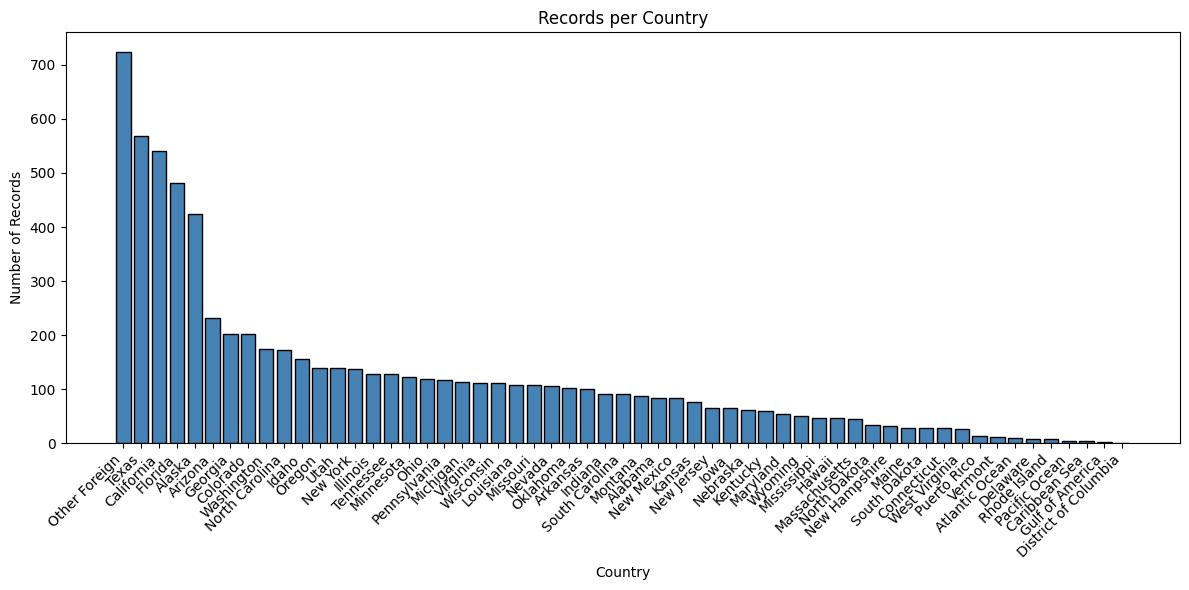

In [9]:
import matplotlib.pyplot as plt
from collections import Counter

def is_float(x):
    return type(x) != float

def plot_country_distribution(records):
    # Assume each record is a dict with a 'country' key
    country_counts = Counter(filter(is_float, records))

    # Sort by frequency
    sorted_counts = dict(sorted(country_counts.items(), key=lambda item: item[1], reverse=True))
    print(sorted_counts)
    
    
    # Plot
    plt.figure(figsize=(12, 6))
    # Use only top 10 countries behind US
    plt.bar(list(sorted_counts.keys()), list(sorted_counts.values()), color='steelblue', edgecolor='black')
    plt.xlabel('Country')
    plt.ylabel('Number of Records')
    plt.title('Records per Country')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

plot_country_distribution(df2['State'])

In [7]:
from datetime import datetime
import pytz

def compare_datetimes(publishedDate, eventDate):
    # Parse first date: "12/2/2022 0:00" (assumed to be local or naive)
    date1 = datetime.strptime(eventDate.strip(), "%m/%d/%Y %H:%M")
    date1 = date1.replace(tzinfo=pytz.UTC)  # Assume UTC; adjust if needed

    # Parse second date: "2020-12-31T18:15:00Z" (ISO 8601 UTC format)
    date2 = datetime.strptime(publishedDate, "%Y-%m-%dT%H:%M:%SZ")
    date2 = date2.replace(tzinfo=pytz.UTC)

    # Calculate time difference
    delta = date1 - date2

    # Return time difference in a friendly format
    return delta.days

#{
#        "days": delta.days,
#        "seconds": delta.total_seconds(),
#        "hours": delta.total_seconds() / 3600,
#    }


### Find distribution over months of year

8411


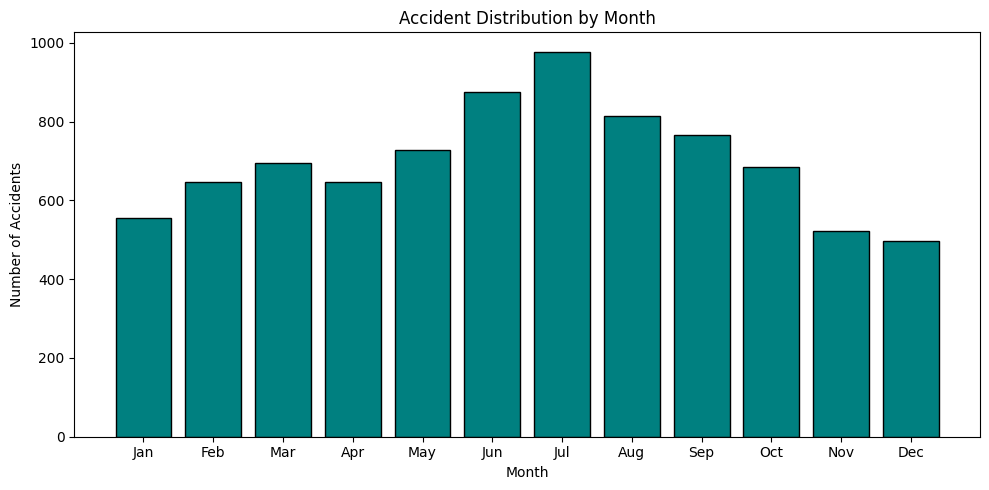

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
from datetime import datetime

def plot_monthly_distribution(dates):
    # Parse dates and extract month numbers (1–12)
    months = [datetime.strptime(date.strip(), "%Y-%m-%dT%H:%M:%SZ").month for date in dates]
    print(len(months))
    # Count occurrences per month
    counts = Counter(months)

    # Ensure all months are represented, even with 0 count
    all_months = list(range(1, 13))
    frequencies = [counts.get(m, 0) for m in all_months]

    # Month labels
    month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    # Plot
    plt.figure(figsize=(10, 5))
    plt.bar(month_labels, frequencies, color='teal', edgecolor='black')
    plt.title('Accident Distribution by Month')
    plt.xlabel('Month')
    plt.ylabel('Number of Accidents')
    plt.tight_layout()
    plt.show()

# Usage
plot_monthly_distribution(df2['EventDate'])

### Find days between event date and publish date of report

C:\Users\michael\AppData\Local\Temp\ipykernel_17068\1229376141.py:8: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  iso_utc_now = datetime.utcnow().replace(tzinfo=timezone.utc).strftime("%m/%d/%Y %H:%M")


[700, 262, 291, 1580, 1580, 232, 673, 197, 1581, 1581, 198, 233, 1582, 707, 1583, 567, 560, 234, 1583, 764, 766, 200, 676, 267, 201, 1585, 268, 1586, 564, 378, 1589, 205, 205, 1589, 241, 617, 567, 683, 667, 242, 569, 774, 669, 209, 670, 606, 782, 685, 636, 573, 247, 282, 1598, 570, 668, 669, 669, 786, 1600, 251, 670, 251, 781, 285, 789, 257, 218, 575, 575, 254, 588, 512, 675, 256, 577, 257, 1606, 619, 1607, 1608, 679, 1609, 320, 796, 679, 1609, 582, 261, 1610, 681, 263, 263, 295, 264, 295, 264, 1613, 265, 1615, 991, 299, 686, 268, 679, 1617, 680, 786, 1619, 281, 301, 661, 593, 284, 277, 594, 599, 237, 238, 238, 1623, 1624, 275, 686, 240, 695, 666, 1626, 277, 611, 1627, 242, 305, 242, 535, 613, 206, 306, 306, 280, 601, 1629, 797, 307, 602, 638, 768, 603, 1631, 247, 287, 1633, 295, 288, 681, 284, 248, 1634, 611, 289, 312, 606, 607, 607, 1056, 286, 815, 1635, 250, 607, 297, 818, 608, 251, 1636, 649, 1638, 868, 253, 665, 650, 254, 301, 703, 255, 765, 1641, 866, 1642, 614, 1642, 294, 1643, 

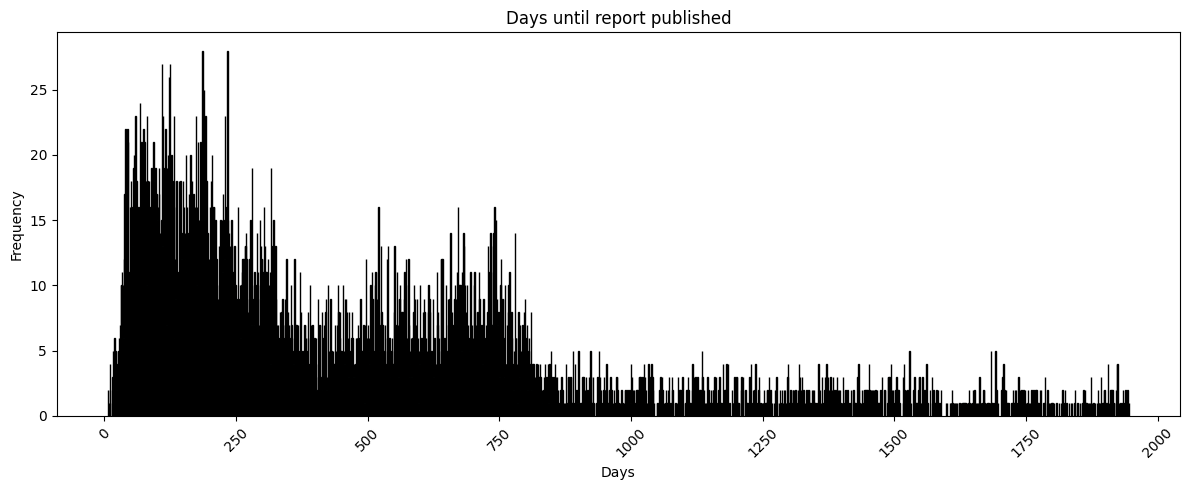

0.0


In [9]:
from datetime import timezone
from collections import Counter
missing = 0
data = []
for index, log in df2.iterrows():
    x = log['OriginalPublishedDate']
    if (type(x) == float):
        iso_utc_now = datetime.utcnow().replace(tzinfo=timezone.utc).strftime("%m/%d/%Y %H:%M")
        timeDelta = compare_datetimes(log['EventDate'], iso_utc_now)
        data.append(timeDelta)
    else: 
        timeDelta = compare_datetimes(log['EventDate'], log['OriginalPublishedDate'])
        data.append(timeDelta)

print(data)

# Count the frequency of each number
freq = Counter(data)
# Separate keys and values
labels = list(freq.keys())
counts = list(freq.values())
# Create a bar plot
plt.figure(figsize=(12, 5))
plt.bar(labels, counts, color='skyblue', edgecolor='black')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.title('Days until report published')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(missing / len(df2))
    

In [25]:
dataF = pd.DataFrame(data)
print(dataF.describe())

                 0
count  5356.000000
mean    345.072069
std     247.023188
min      21.000000
25%     134.750000
50%     258.000000
75%     560.000000
max    1414.000000
